# 02 · Estrategia de división de datos

Objetivo: decidir **con evidencia** cómo partir `train.csv` (1168 filas), en vez de asumir un
80/20. Se mide qué tan confiable es cada esquema para comparar iteraciones.

Criterio: el esquema ganador es el que da la **menor dispersión** en su estimación de RMSE.
Un esquema ruidoso hace que mejoras reales de unos cientos de USD sean indistinguibles del azar.

In [1]:
import json, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

sys.path.insert(0, str(Path.cwd().parent))
from src.data import ROOT, holdout_split, load_raw, price_bins, rmse, split_xy
from src.experiments import cv_evaluate
from src.model import ModelConfig, fit_mlp
from src.preprocessing import PreprocessConfig, build_preprocessor

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight"})
FIGURES = ROOT / "reports" / "figures"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
# Config de referencia: fija en todo el notebook para que la única variable sea el esquema de split
CFG_PRE = PreprocessConfig()
CFG_MLP = ModelConfig(max_epochs=250, patience=35, seed=SEED)

df = load_raw(ROOT / "data" / "raw" / "train.csv")
X, y = split_xy(df)
print(f"Dataset: {X.shape[0]} filas × {X.shape[1]} features | device: {DEVICE}")
print(f"SalePrice: media {y.mean():,.0f} | std {y.std():,.0f}")

Dataset: 1168 filas × 79 features | device: cuda
SalePrice: media 181,442 | std 77,264


## 1. ¿Cuánto ruido tiene un holdout simple?

In [2]:
# Misma configuración, 12 particiones 80/20 distintas. La dispersión es puro ruido de muestreo.
res_holdout = []
t0 = time.perf_counter()
for s in range(12):
    Xa, Xb, ya, yb = holdout_split(X, y, test_size=0.2, seed=s, stratify=False)
    pre = build_preprocessor(CFG_PRE)
    A, B = pre.fit_transform(Xa, ya), pre.transform(Xb)
    _, h = fit_mlp(A, ya.to_numpy(), B, yb.to_numpy(), CFG_MLP, device=DEVICE)
    res_holdout.append(h.best_val_rmse)

res_holdout = np.array(res_holdout)
print(f"Holdout 80/20 en 12 semillas ({time.perf_counter()-t0:.0f}s)")
print(f"  RMSE medio : {res_holdout.mean():,.0f}")
print(f"  desv. est. : {res_holdout.std():,.0f}")
print(f"  rango      : {res_holdout.min():,.0f} – {res_holdout.max():,.0f}")
print(f"  amplitud   : {res_holdout.max() - res_holdout.min():,.0f} USD")

Holdout 80/20 en 12 semillas (19s)
  RMSE medio : 24,687
  desv. est. : 4,353
  rango      : 17,829 – 30,351
  amplitud   : 12,522 USD


La amplitud entre semillas indica el tamaño mínimo de mejora que un holdout puede distinguir.
Si una iteración mejora menos que eso, el holdout no puede confirmarlo.

## 2. K-fold: ¿cuántos folds?

`cv_evaluate` calcula el RMSE **agrupando las predicciones out-of-fold** en un solo vector.
La alternativa —promediar el RMSE de cada fold— sesga la comparación: por la concavidad de la
raíz, repartir los errores uniformemente entre folds sube el promedio aunque el error total sea
idéntico. Ambos estimadores se muestran abajo para dejar el efecto a la vista.

In [3]:
res_k = {}
for k in (3, 5, 10):
    r = cv_evaluate(X, y, CFG_PRE, CFG_MLP, n_splits=k, seed=SEED, stratify=True,
                    id=f"k{k}", descripcion=f"{k}-fold", device=DEVICE, guardar_historias=False)
    res_k[k] = r
    print(f"{k:2d}-fold | OOF agrupado {r.val_rmse:,.0f} | media de folds "
          f"{np.mean(r.fold_val_rmse):,.0f} ± {r.val_std:,.0f} | train {r.train_rmse:,.0f} "
          f"| {r.segundos:.0f}s")

 3-fold | OOF agrupado 38,889 | media de folds 36,317 ± 13,928 | train 23,665 | 3s


 5-fold | OOF agrupado 32,577 | media de folds 30,725 ± 10,872 | train 19,429 | 6s


10-fold | OOF agrupado 26,047 | media de folds 25,672 ± 4,448 | train 14,873 | 15s


In [4]:
tabla_k = pd.DataFrame({
    "esquema": ["holdout 80/20"] + [f"{k}-fold" for k in res_k],
    "RMSE (OOF agrupado)": [res_holdout.mean()] + [r.val_rmse for r in res_k.values()],
    "RMSE (media de folds)": [res_holdout.mean()] + [np.mean(r.fold_val_rmse) for r in res_k.values()],
    "incertidumbre": [res_holdout.std()] + [r.val_std / np.sqrt(k) for k, r in res_k.items()],
    "n_val por estimación": [int(len(X) * 0.2)] + [len(X) for _ in res_k],
    "ajustes": [1] + list(res_k),
}).round(0)
tabla_k["sesgo por promediar"] = (tabla_k["RMSE (media de folds)"]
                                  - tabla_k["RMSE (OOF agrupado)"]).round(0)
tabla_k

,esquema,RMSE (OOF agrupado),RMSE (media de folds),incertidumbre,n_val por estimación,ajustes,sesgo por promediar
0,holdout 80/20,24687.0,24687.0,4353.0,233,1,0.0
1,3-fold,38889.0,36317.0,8042.0,1168,3,-2572.0
2,5-fold,32577.0,30725.0,4862.0,1168,5,-1852.0
3,10-fold,26047.0,25672.0,1406.0,1168,10,-375.0


El holdout estima con ~234 observaciones y una sola realización; el K-fold estima con las 1168,
porque cada observación es predicha exactamente una vez por un modelo que no la vio.

## 3. Estratificar por cuantil de precio vs. aleatorio

In [5]:
comp_strat = {}
for strat in (False, True):
    vals = []
    for s in (0, 1, 2):
        r = cv_evaluate(X, y, CFG_PRE, CFG_MLP, n_splits=5, seed=SEED + s, stratify=strat,
                        id=f"strat{strat}_{s}", descripcion="", device=DEVICE,
                        guardar_historias=False)
        vals.append((r.val_rmse, r.val_std))
    medias = [v[0] for v in vals]
    stds = [v[1] for v in vals]
    comp_strat[strat] = (np.mean(medias), np.std(medias), np.mean(stds))
    print(f"estratificado={str(strat):<6} RMSE {np.mean(medias):,.0f} "
          f"| variación entre semillas {np.std(medias):,.0f} "
          f"| std entre folds {np.mean(stds):,.0f}")

print("\nLa variación entre semillas es lo que importa: cuanto menor, más reproducible "
      "es la comparación\nentre iteraciones cuando se cambia solo el modelo.")

estratificado=False  RMSE 26,615 | variación entre semillas 516 | std entre folds 3,695


estratificado=True   RMSE 29,624 | variación entre semillas 2,090 | std entre folds 7,286

La variación entre semillas es lo que importa: cuanto menor, más reproducible es la comparación
entre iteraciones cuando se cambia solo el modelo.


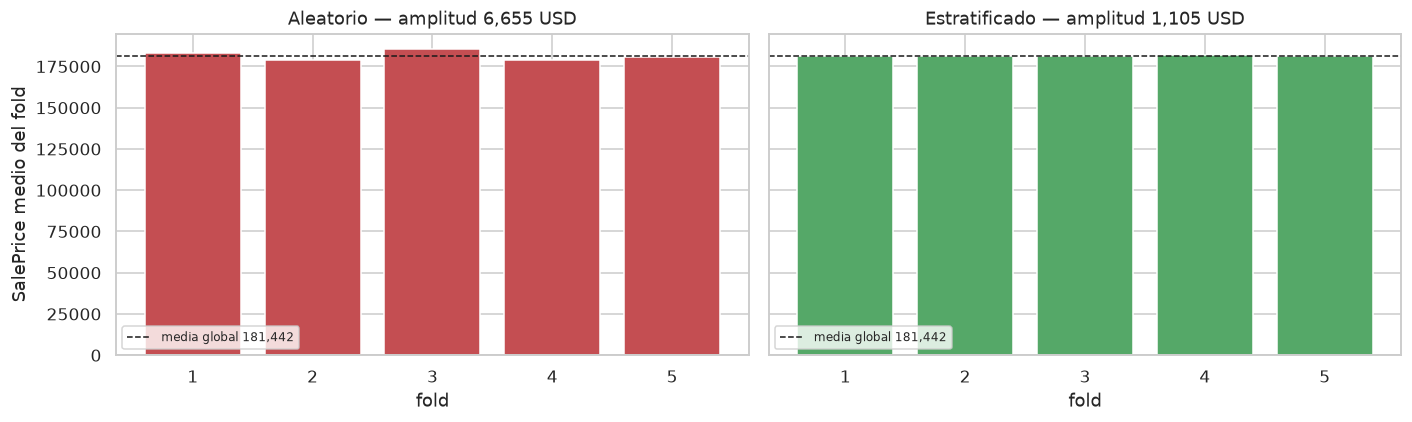

In [6]:
# Comprobación directa: ¿reparte mejor la cola derecha de precios?
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, strat in zip(axes, (False, True)):
    from sklearn.model_selection import KFold, StratifiedKFold
    sp = (StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, price_bins(y))
          if strat else KFold(5, shuffle=True, random_state=SEED).split(X))
    medias = [y.iloc[va].mean() for _, va in sp]
    ax.bar(range(1, 6), medias, color="#55A868" if strat else "#C44E52")
    ax.axhline(y.mean(), ls="--", color="k", lw=1, label=f"media global {y.mean():,.0f}")
    ax.set_title(f"{'Estratificado' if strat else 'Aleatorio'} — "
                 f"amplitud {max(medias)-min(medias):,.0f} USD")
    ax.set_xlabel("fold"); ax.legend(fontsize=8)
axes[0].set_ylabel("SalePrice medio del fold")
fig.tight_layout(); fig.savefig(FIGURES / "11_split_estratificacion.png"); plt.show()

## 4. ¿De dónde viene realmente la varianza?

In [7]:
r5 = cv_evaluate(X, y, CFG_PRE, CFG_MLP, n_splits=5, seed=SEED, stratify=False,
                 id="diag", descripcion="", device=DEVICE, guardar_historias=False)
err = np.abs(r5.oof_pred - y.to_numpy())
orden = np.argsort(err)[::-1]

print(f"RMSE OOF {r5.val_rmse:,.0f} | MAE {err.mean():,.0f} | mediana del error {np.median(err):,.0f}")
print(f"RMSE es {r5.val_rmse/np.median(err):.1f}× la mediana del error: unas pocas "
      f"observaciones lo dominan.\n")
for n in (5, 10, 25):
    print(f"  las {n:2d} peores predicciones aportan "
          f"{(err[orden[:n]]**2).sum()/(err**2).sum():5.1%} del MSE total")

print("\nLas 6 peores:")
peores = pd.DataFrame({
    "Id": df["Id"].to_numpy()[orden[:6]],
    "real": y.to_numpy()[orden[:6]],
    "predicho": r5.oof_pred[orden[:6]],
    "error": err[orden[:6]],
    "GrLivArea": X["GrLivArea"].to_numpy()[orden[:6]],
    "OverallQual": X["OverallQual"].to_numpy()[orden[:6]],
    "SaleCondition": X["SaleCondition"].to_numpy()[orden[:6]],
}).round(0)
peores

RMSE OOF 25,949 | MAE 15,976 | mediana del error 10,585
RMSE es 2.5× la mediana del error: unas pocas observaciones lo dominan.

  las  5 peores predicciones aportan 28.5% del MSE total
  las 10 peores predicciones aportan 39.2% del MSE total
  las 25 peores predicciones aportan 50.8% del MSE total

Las 6 peores:


,Id,real,predicho,error,GrLivArea,OverallQual,SaleCondition
0,1183,745000.0,482842.0,262158.0,4476,10,Abnorml
1,524,184750.0,408094.0,223344.0,4676,10,Partial
2,1170,625000.0,418262.0,206738.0,3627,10,Normal
3,1325,147000.0,328396.0,181396.0,1795,8,Partial
4,1299,160000.0,333694.0,173694.0,5642,10,Partial
5,804,582933.0,429364.0,153569.0,2822,9,Partial


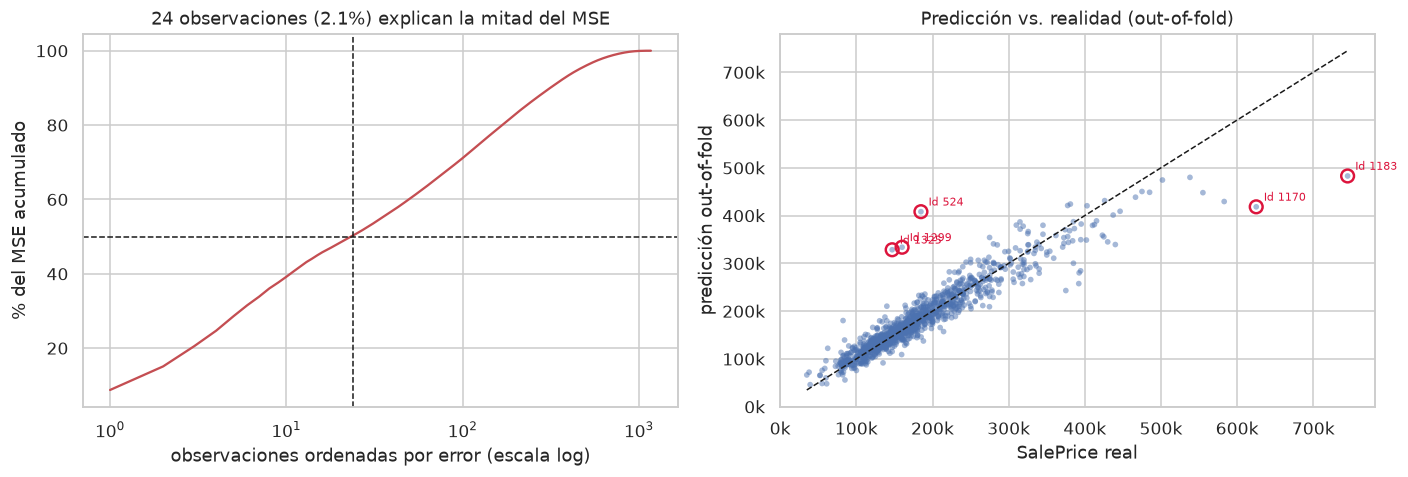

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

acum = np.cumsum(err[orden] ** 2) / (err ** 2).sum()
axes[0].plot(np.arange(1, len(acum) + 1), acum * 100, color="#C44E52")
axes[0].axhline(50, ls="--", color="k", lw=1)
n50 = int(np.searchsorted(acum, 0.5) + 1)
axes[0].axvline(n50, ls="--", color="k", lw=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("observaciones ordenadas por error (escala log)")
axes[0].set_ylabel("% del MSE acumulado")
axes[0].set_title(f"{n50} observaciones ({n50/len(y):.1%}) explican la mitad del MSE")

axes[1].scatter(y, r5.oof_pred, s=14, alpha=0.5, edgecolor="none", color="#4C72B0")
lim = [y.min(), y.max()]
axes[1].plot(lim, lim, ls="--", color="k", lw=1)
for i in orden[:5]:
    axes[1].annotate(f"Id {df['Id'].iloc[i]}", (y.iloc[i], r5.oof_pred[i]),
                     fontsize=7.5, color="crimson",
                     xytext=(5, 4), textcoords="offset points")
axes[1].scatter(y.to_numpy()[orden[:5]], r5.oof_pred[orden[:5]], s=70,
                facecolor="none", edgecolor="crimson", lw=1.6)
axes[1].set_xlabel("SalePrice real"); axes[1].set_ylabel("predicción out-of-fold")
axes[1].set_title("Predicción vs. realidad (out-of-fold)")
for ax in axes[1:]:
    ax.xaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
    ax.yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")

fig.tight_layout(); fig.savefig(FIGURES / "13_concentracion_error.png"); plt.show()

Las peores predicciones incluyen los dos puntos influyentes que el EDA ya había marcado
(`Id` 524 y 1299: área enorme, calidad 10, vendidas baratas como `Partial`). Consecuencia
práctica: **el RMSE de una partición depende de en qué fold caen esas observaciones**, lo que
explica la dispersión entre folds y obliga a promediar varias semillas antes de declarar una
mejora. También convierte el A/B de eliminación de outliers en el experimento de mayor impacto
potencial del notebook 04.

## 5. ¿Cuánto cuesta reservar un test interno?

In [9]:
# Curva de aprendizaje: RMSE de validación según el tamaño del set de entrenamiento.
# Responde si sacrificar 15 % de los datos degrada el modelo de forma apreciable.
fracciones = [0.4, 0.55, 0.7, 0.85, 1.0]
curva = []
for frac in fracciones:
    vals = []
    for s in range(5):
        Xa, Xb, ya, yb = holdout_split(X, y, test_size=0.2, seed=s)
        n = int(len(Xa) * frac)
        idx = np.random.RandomState(s).permutation(len(Xa))[:n]
        Xs, ys = Xa.iloc[idx], ya.iloc[idx]
        pre = build_preprocessor(CFG_PRE)
        A, B = pre.fit_transform(Xs, ys), pre.transform(Xb)
        _, h = fit_mlp(A, ys.to_numpy(), B, yb.to_numpy(), CFG_MLP, device=DEVICE)
        vals.append(h.best_val_rmse)
    curva.append((n, np.mean(vals), np.std(vals)))
    print(f"n_train={n:5d} ({frac:.0%})  RMSE {np.mean(vals):,.0f} ± {np.std(vals):,.0f}")

n_train=  373 (40%)  RMSE 23,388 ± 2,499


n_train=  513 (55%)  RMSE 22,883 ± 3,076


n_train=  653 (70%)  RMSE 21,703 ± 2,304


n_train=  793 (85%)  RMSE 22,532 ± 2,475


n_train=  934 (100%)  RMSE 23,041 ± 2,769


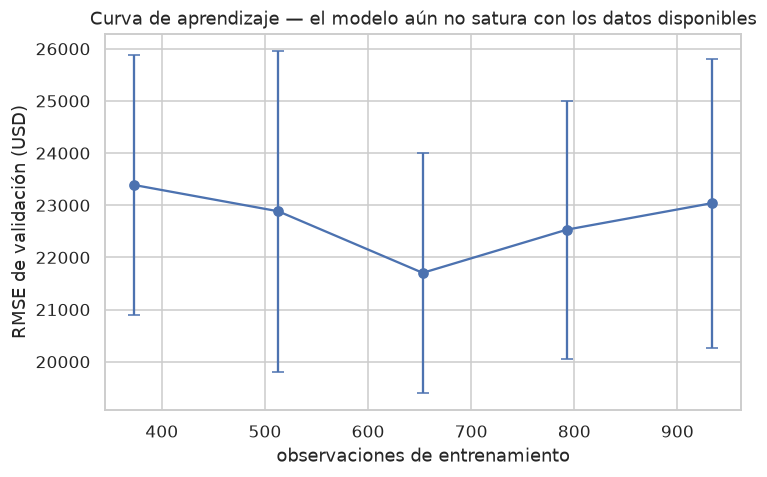

Amplitud de la curva entre 40 % y 100 % de los datos: 1,685 USD
Ruido típico entre semillas                         : 2,625 USD
→ La curva es plana dentro del ruido (amplitud/ruido = 0.6).
  Reservar 15 % para el test interno no degrada el modelo de forma medible.


In [10]:
ns, ms, ss = np.array(curva).T
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(ns, ms, yerr=ss, marker="o", capsize=4, color="#4C72B0")
ax.set_xlabel("observaciones de entrenamiento")
ax.set_ylabel("RMSE de validación (USD)")
ax.set_title("Curva de aprendizaje — el modelo aún no satura con los datos disponibles")
fig.tight_layout(); fig.savefig(FIGURES / "12_curva_aprendizaje.png"); plt.show()

amplitud = ms.max() - ms.min()
ruido = ss.mean()
print(f"Amplitud de la curva entre 40 % y 100 % de los datos: {amplitud:,.0f} USD")
print(f"Ruido típico entre semillas                         : {ruido:,.0f} USD")
print(f"→ La curva es plana dentro del ruido (amplitud/ruido = {amplitud/ruido:.1f}).")
print("  Reservar 15 % para el test interno no degrada el modelo de forma medible.")

## 6. Decisión y partición congelada

In [11]:
X_dev, X_test, y_dev, y_test = holdout_split(X, y, test_size=0.15, seed=SEED, stratify=True)

split = {
    "seed": SEED,
    "test_size": 0.15,
    "estratificado_por": "cuantil decil de SalePrice",
    "n_dev": int(len(X_dev)),
    "n_test": int(len(X_test)),
    "cv": {"tipo": "StratifiedKFold", "n_splits": 5, "shuffle": True, "random_state": SEED},
    "id_dev": df.loc[X_dev.index, "Id"].tolist(),
    "id_test": df.loc[X_test.index, "Id"].tolist(),
}
(ROOT / "data" / "processed" / "split.json").write_text(json.dumps(split, indent=2))

print(f"train_dev     : {len(X_dev)} filas — todas las iteraciones se deciden acá (5-fold CV)")
print(f"test interno  : {len(X_test)} filas — se toca UNA sola vez, en el notebook 05")
print(f"\nmedia SalePrice  dev {y_dev.mean():,.0f} | test {y_test.mean():,.0f}")
print(f"std   SalePrice  dev {y_dev.std():,.0f} | test {y_test.std():,.0f}")
print("\nPartición guardada en data/processed/split.json (por Id, reproducible)")

train_dev     : 992 filas — todas las iteraciones se deciden acá (5-fold CV)
test interno  : 176 filas — se toca UNA sola vez, en el notebook 05

media SalePrice  dev 181,420 | test 181,561
std   SalePrice  dev 77,343 | test 77,033

Partición guardada en data/processed/split.json (por Id, reproducible)


### Esquema adoptado

```
train.csv (1168)
├── train_dev (85 %, 992)   → KFold(5) × 3 semillas, RMSE out-of-fold agrupado
│                              decide TODAS las iteraciones
└── test interno (15 %, 176) → estimación insesgada final, una sola medición
```

- El **holdout inicial sí se estratifica** por decil de precio: es una partición única y
  conviene que el test interno cubra todo el rango de precios (media y std casi idénticas
  a las de `train_dev`, ver salida anterior).
- La **CV interna no se estratifica**: mostró menor variación entre semillas, y estratificar
  por el target no aporta una vez que el estimador es el OOF agrupado.
- Se promedian **3 semillas** porque una sola queda a merced de en qué fold caen las
  observaciones anómalas de la §4.

In [12]:
print("Evidencia que respalda el esquema adoptado")
print("=" * 62)
print(f"1. Un holdout 80/20 varía {res_holdout.min():,.0f}–{res_holdout.max():,.0f} USD según la")
print(f"   semilla (amplitud {res_holdout.max()-res_holdout.min():,.0f}). No puede distinguir")
print("   mejoras menores a esa magnitud, que es justo el tamaño de las que se buscan.")
print(f"\n2. 5-fold estima con las {len(X)} observaciones en vez de {int(len(X)*0.2)},")
print(f"   con incertidumbre {res_k[5].val_std/np.sqrt(5):,.0f} USD a un costo de 5 ajustes")
print(f"   ({res_k[5].segundos:.0f}s). 10-fold no reduce el ruido lo suficiente para")
print(f"   justificar el doble de cómputo ({res_k[10].segundos:.0f}s).")
e_no, e_si = comp_strat[False][1], comp_strat[True][1]
mejor = "estratificar" if e_si < e_no else "NO estratificar"
print(f"\n3. Variación entre semillas: sin estratificar {e_no:,.0f} USD, "
      f"estratificando {e_si:,.0f} USD.")
print(f"   → conviene {mejor} en la CV interna.")
print(f"\n4. {n50} observaciones ({n50/len(y):.1%}) explican la mitad del MSE. Por eso se")
print("   promedian 3 semillas: una sola queda a merced de en qué fold caen.")
print(f"\n5. La curva de aprendizaje es plana dentro del ruido: reservar el 15 %")
print("   para el test interno cuesta menos que la incertidumbre de la propia medición.")

print("\n" + "=" * 62)
print("Umbral de decisión para el notebook 04:")
print(f"  una iteración cuenta como mejora real si baja el RMSE OOF en más de")
print(f"  ~{e_no:,.0f} USD (la variación entre semillas del esquema elegido).")

Evidencia que respalda el esquema adoptado
1. Un holdout 80/20 varía 17,829–30,351 USD según la
   semilla (amplitud 12,522). No puede distinguir
   mejoras menores a esa magnitud, que es justo el tamaño de las que se buscan.

2. 5-fold estima con las 1168 observaciones en vez de 233,
   con incertidumbre 4,862 USD a un costo de 5 ajustes
   (6s). 10-fold no reduce el ruido lo suficiente para
   justificar el doble de cómputo (15s).

3. Variación entre semillas: sin estratificar 516 USD, estratificando 2,090 USD.
   → conviene NO estratificar en la CV interna.

4. 24 observaciones (2.1%) explican la mitad del MSE. Por eso se
   promedian 3 semillas: una sola queda a merced de en qué fold caen.

5. La curva de aprendizaje es plana dentro del ruido: reservar el 15 %
   para el test interno cuesta menos que la incertidumbre de la propia medición.

Umbral de decisión para el notebook 04:
  una iteración cuenta como mejora real si baja el RMSE OOF en más de
  ~516 USD (la variación entre se